# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [1]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_raw_macro.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint

In [142]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
#! pip install goatools
#!pip install leidenalg

In [3]:
adata = sc.read(input_file) # read data 
if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


=== This dataset is now normalised
=== Cell type and macrostates in our dataset
['B intermediate' 'B naive' 'B' 'B memory' 'Bridge']
['I2' 'None' 'I1' 'T1' 'T3' 'T2']


# 1) Evaluate the pathway enrichement per macrostate (before HVG and binarization)

macrostates
I1    5018
T2    1797
T3    1699
I2    1015
T1     264
Name: count, dtype: int64


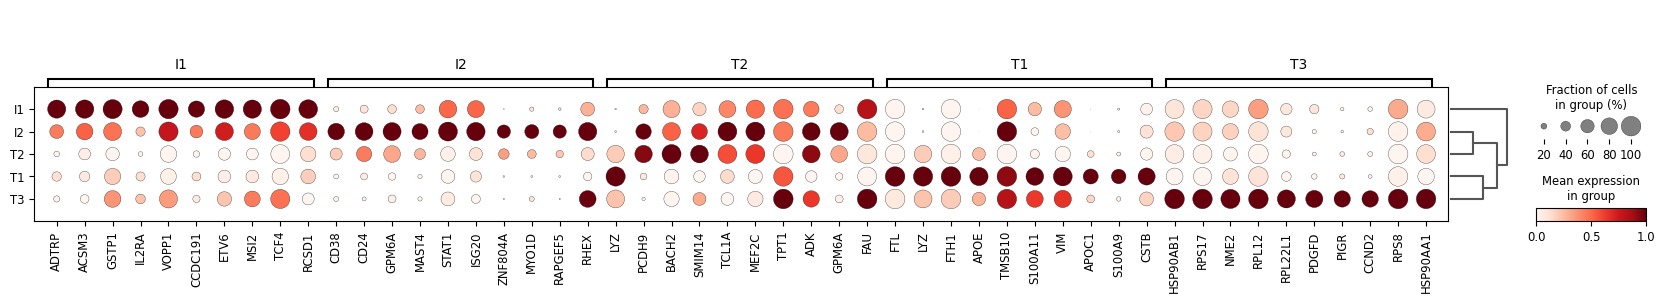

/tmp/ipykernel_9396/3067979434.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")
/tmp/ipykernel_9396/3067979434.py:63: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


In [8]:
# Goal define specific pathways for each macrostates 

# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()
print(adata_no_none.obs["macrostates"].value_counts())

# DEG between the macrostates 
sc.tl.rank_genes_groups(adata_no_none, groupby="macrostates", method="wilcoxon", use_raw=False)
sc.pl.rank_genes_groups_dotplot(adata_no_none, groupby="macrostates", standard_scale="var", n_genes=10, show=False)
plt.savefig(f"{output_directory}/dotplot_macro_deg.png", dpi=300,bbox_inches="tight")
plt.show()

# Genes up-regulated 
result = adata_no_none.uns["rank_genes_groups"]
groups = result["names"].dtype.names
deg_list = {}
for group in groups:
    df = pd.DataFrame({
        "gene": result["names"][group],
        "logfc": result["logfoldchanges"][group],
        "pval": result["pvals_adj"][group]
    })
    # Filter (pvalue < 0.05 and logfc > 0.25)
    df = df[(df["pval"] < 0.05) & (df["logfc"] > 0.25)]
    deg_list[group] = df

macrostates = ["I1", "I2", "T1", "T2", "T3"]
deg_lists = {
    ct: deg_list[ct]["gene"].tolist()
    for ct in macrostates}

cmap = cm.get_cmap("RdBu_r")

for ct in macrostates:
    # 1) Enrichment Reactome per macrostate
    enr = gp.enrichr(gene_list=deg_lists[ct],gene_sets="Reactome_Pathways_2024",organism="human",outdir=None)
    res = enr.results.copy()
    res = res.sort_values("Adjusted P-value").head(8)  # top 8 termes
    res["logp"] = -np.log10(res["Adjusted P-value"])

    vmin, vmax = res["logp"].min(), res["logp"].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # 2) 1 figure for each macrostate
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [cmap(norm(v)) for v in res["logp"]]

    # Horizontal bar
    ax.barh(res["Term"],res["Combined Score"],color=colors,height=0.5)

    ax.invert_yaxis()
    ax.set_title(f"{ct}", fontsize=20)
    ax.set_xlabel("Combined Score", fontsize=14)
    ax.tick_params(axis="y", labelsize=20, pad=6)   # noms de pathways
    ax.tick_params(axis="x", labelsize=12)
    # 3) Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("-log10(adj p-value)", fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    # 4) Save
    fig.tight_layout()
    fig.savefig(f"{output_directory}/reactome_barplot_{ct}.png",dpi=300,bbox_inches="tight")
    plt.close(fig)

# 2) Binarization with scBoolSeq

Binarization macrostates separately

In [46]:
if macrostates_computed=="timepoint":
    mapping = {0: "I1",1: "I2",2: "T1",3: "T2",4: "T3",5: "None"}
    adata.obs["macrostates"] = adata.obs["macrostates"].map(mapping)
    print(adata.obs["macrostates"].unique())

In [117]:
warnings.filterwarnings("ignore")
macrostates = ['I1', 'I2', 'T1', 'T2', "T3"]

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
    
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG adapted to the cell type size
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : Building the DataFrame for scBoolSeq
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Eliminate the 0 genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : Fit scBoolSeq on all the cell of the macrostate
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",# use quantile thresholds for zero-inflated genes
        margin_quantile=0.1, # 10th/90th percentile instead of 5th/95th
        dor_threshold=0.85, # classify as zero-inflated if >85% zeros
        alpha=0.0, # no IQR expansion (keep it simple)
    )
    scbool.fit(expr_df_full)
    print(f"  scBoolSeq fitted")

    # STEP 4 : Binarize per macrostate
    binarized = scbool.binarize(expr_df_full)

    # STEP 5 : Majority vote sur toutes les cellules
    def majority_vote(col):
        valid = col.dropna()
        if len(valid) == 0:
            return np.nan
        frac_ones = (valid == 1).mean()
        if frac_ones >= 0.5:
            return 1
        elif (valid == 0).mean() >= 0.5:
            return 0
        else:
            return np.nan

    aggregated = binarized.apply(majority_vote, axis=0)
    binarized_states[ct] = aggregated

    n_ones  = (aggregated == 1).sum()
    n_zeros = (aggregated == 0).sum()
    n_nan   = aggregated.isna().sum()
    print(f"  {ct}: {n_cells} cells → {n_ones} genes=1, {n_zeros} genes=0, {n_nan} genes=NaN")

    del adata_ct, expr_df_full, scbool
    gc.collect()

print("\nDone!")


Processing I1...
  5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  I1: 5018 cells → 694 genes=1, 90 genes=0, 1216 genes=NaN

Processing I2...
  1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  I2: 1015 cells → 768 genes=1, 148 genes=0, 1084 genes=NaN

Processing T1...
  264 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  T1: 264 cells → 531 genes=1, 52 genes=0, 1417 genes=NaN

Processing T2...
  1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  T2: 1797 cells → 404 genes=1, 186 genes=0, 1410 genes=NaN

Processing T3...
  1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  T3: 1699 cells → 726 genes=1, 102 genes=0, 1172 genes=NaN

Done!


In [118]:
pd.DataFrame.from_dict(binarized_states, orient="index").fillna('')

,KLHL17,ISG15,TNFRSF4,B3GALT6,MMP23B,PRKCZ,ARHGEF16,DFFB,RNF207,ESPN,...,DCX,WDR44,IL13RA1,LONRF3,PHF6,SMIM10,RTL8B,ZNF449,CD40LG,L1CAM
I1,,1.0,,,,,,,,,...,,,,,,,,,,
I2,,1.0,,,,,,,,,...,,,,,,,,,,
T2,,1.0,,,,,,,,,...,,,,,,,,,,
T3,,1.0,,,,,,,,,...,,1.0,,,1.0,,,,,
T1,,,,,,,,,,,...,,,,,,,,,,


In [119]:
all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])
print(f"Total genes: {len(all_genes)}")
print(f"HVG macrostates: {hvg_mask.sum()} genes")

Total genes: 18723
HVG macrostates: 6214 genes


# 3) Evaluate the HVG selection

Scatter Plot

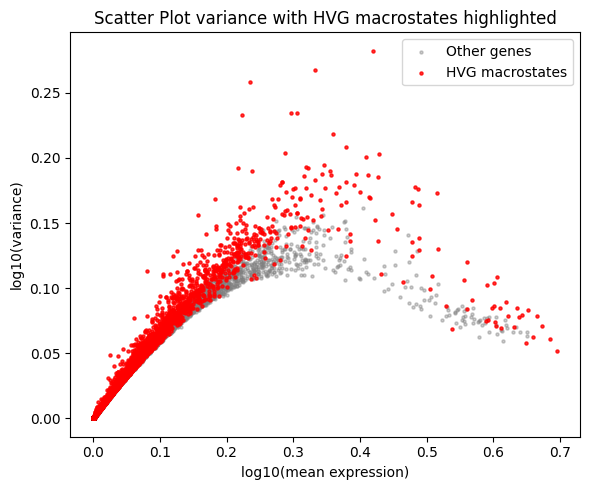

In [120]:
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# Mean and variance per gene
means = np.mean(X, axis=0)      # (n_genes,)
vars_  = np.var(X, axis=0)      # (n_genes,)

log_means = np.log10(means + 1)
log_vars  = np.log10(vars_ + 1)

all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])

# Scatter plot mean–variance
plt.figure(figsize=(6, 5))
plt.scatter(
    log_means[~hvg_mask], log_vars[~hvg_mask],
    s=5, alpha=0.4, label="Other genes",
    c="gray")
plt.scatter(
    log_means[hvg_mask], log_vars[hvg_mask],
    s=5, alpha=0.8, label="HVG macrostates",
    c="red")
plt.xlabel("log10(mean expression)")
plt.ylabel("log10(variance)")
plt.title("Scatter Plot variance with HVG macrostates highlighted")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_directory}/scatterplot_macro.png", dpi=500, bbox_inches='tight')
plt.show()

Ratio variance inter and intra macrostates

In [121]:
print("Building global HVG matrix...")
all_hvg = list(all_hvg)
adata_hvg = adata[:, all_hvg].copy()

X = adata_hvg.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

valid_states = ['I1', 'I2', 'T1', 'T2', 'T3']
adata_hvg = adata_hvg[adata_hvg.obs['macrostates'].isin(valid_states)].copy()

labels = adata_hvg.obs['macrostates'].values
print("Compute intra variance...")
intra_var = []
for c in np.unique(labels):
    idx = np.where(labels == c)[0]
    if len(idx) > 1:
        intra_var.append(np.mean(np.var(X[idx, :], axis=0)))

intra_var_mean = np.mean(intra_var)
print("Compute inter variance...")
means_per_cluster = np.array([
    X[np.where(labels == c)[0], :].mean(axis=0)
    for c in np.unique(labels)
])

inter_var = np.mean(np.var(means_per_cluster, axis=0))
ratio = inter_var / intra_var_mean if intra_var_mean > 0 else np.nan

print(f"Inter/Intra macrostate ratio: {ratio:.4f}")

Building global HVG matrix...
Compute intra variance...
Compute inter variance...
Inter/Intra macrostate ratio: 0.0035


AMI (Ajusted Mutual Information)

In [49]:
resolutions = np.arange(0.1, 1, 0.1)
resolution = []
ami_tg_vals = [] # HVG per macrostates vs all genes 
ami_global_vals = [] # HVG per macrostates vs HVG global 
ami_hvg_vals = [] # HVG global vs all genes 
n_clust_tg = []
n_clust_macro = []
n_clust_global= []

# 1) PCA 
# Clustering based on all the genes
adata_tg = adata.copy()
sc.tl.pca(adata_tg, n_comps=n_pcs, use_highly_variable=False)
# Clustering based on the HVG per macrostates
all_genes = adata.var_names
hvg_mask_macro = np.array([gene in all_hvg for gene in all_genes])
adata_hvg_macro = adata[:, hvg_mask_macro].copy()
sc.tl.pca(adata_hvg_macro, n_comps=n_pcs, use_highly_variable=False)
# Clustering based on the HVG on the complete population (all cells) 
adata_hvg_global = adata.copy()
sc.pp.highly_variable_genes(adata_hvg_global,n_top_genes=2000,flavor="cell_ranger")
sc.tl.pca(adata_hvg_global, n_comps=n_pcs, use_highly_variable=True)

for res in resolutions:

    # Clustering TG (all the gene)
    sc.pp.neighbors(adata_tg, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(adata_tg, resolution=res, key_added="leiden_TG_tmp")
    y_tg = adata_tg.obs["leiden_TG_tmp"]

    # Clustering HVG macrostates
    sc.pp.neighbors(adata_hvg_macro, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(adata_hvg_macro, resolution=res, key_added="leiden_HVG_macro_tmp")
    y_macro = adata_hvg_macro.obs["leiden_HVG_macro_tmp"]

    # Clustering HVG all cells
    sc.pp.neighbors(adata_hvg_global, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(adata_hvg_global, resolution=res, key_added="leiden_HVG_global_tmp")
    y_global = adata_hvg_global.obs["leiden_HVG_global_tmp"]

    # Clusters number
    n_clust_tg.append(len(np.unique(y_tg)))
    n_clust_macro.append(len(np.unique(y_macro)))
    n_clust_global.append(len(np.unique(y_global)))

    # ARI
    ari_tg = adjusted_rand_score(y_macro, y_tg)
    ari_global = adjusted_rand_score(y_macro, y_global)
    # AMI 
    ami_tg = adjusted_mutual_info_score(y_macro, y_tg)
    ami_global = adjusted_mutual_info_score(y_macro, y_global)
    ami_hvg = adjusted_mutual_info_score(y_tg, y_global)

    resolution.append(res)
    ari_tg_vals.append(ari_tg)
    ari_global_vals.append(ari_global)
    ami_tg_vals.append(ami_tg)
    ami_hvg_vals.append(ami_hvg)
    ami_global_vals.append(ami_global)

print("Minimum clusters number : ")
print(f"AMI (all genes)      : {min(n_clust_tg)}")
print(f"AMI (HVG macro)      : {min(n_clust_macro)}")
print(f"AMI (HVG)      : {min(n_clust_global)}")

print("Maximum clusters number : ")
print(f"AMI (all genes)      : {max(n_clust_tg)}")
print(f"AMI (HVG macro)      : {max(n_clust_macro)}")
print(f"AMI (HVG)      : {max(n_clust_global)}")

Minimum clusters number : 
AMI (all genes)      : 4
AMI (HVG macro)      : 4
AMI (HVG)      : 4
Maximum clusters number : 
AMI (all genes)      : 15
AMI (HVG macro)      : 14
AMI (HVG)      : 14


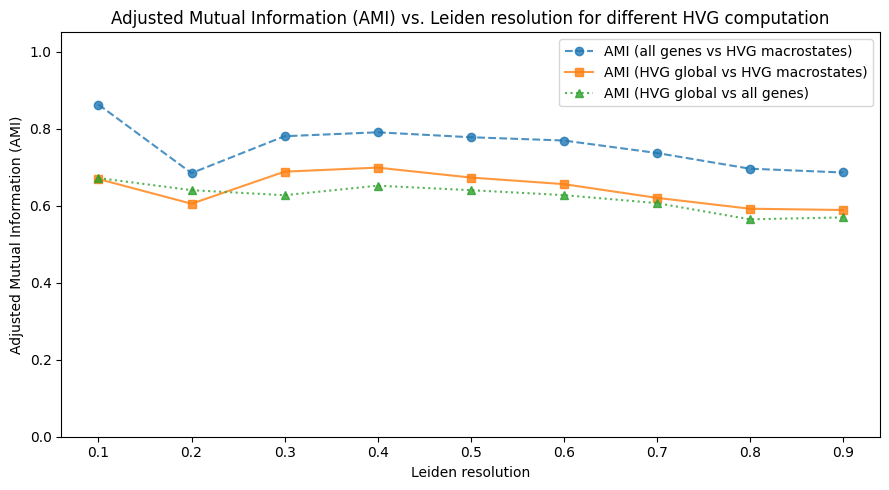

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))

# AMI (all genes vs HVG macrostates)
ax.plot(resolution, ami_tg_vals,"o--", label="AMI (all genes vs HVG macrostates)", alpha=0.8)
# AMI (HVG all cells vs HVG macrostates)
ax.plot(resolution, ami_global_vals,"s-", label="AMI (HVG global vs HVG macrostates)", alpha=0.8)
# AMI (HVG all cells vs HVG macrostates)
ax.plot(resolution, ami_hvg_vals,"^:", label="AMI (HVG global vs all genes)", alpha=0.8)

# Axis
ax.set_xlabel("Leiden resolution")
ax.set_ylabel("Adjusted Mutual Information (AMI)")
ax.set_ylim(0, 1.05)
#Title
ax.set_title("Adjusted Mutual Information (AMI) vs. Leiden resolution for different HVG computation")
# Legend
ax.legend()
# Save
plt.tight_layout()
plt.savefig(f"{output_directory}/ami_vs_n_clusters_3curves.png", dpi=300, bbox_inches="tight")
plt.show()

Pathway enrichment (Scanpy or AUCell)

In [106]:
immune_pathways = {
    k: v for k, v in reactome.items()
    if "costimulation " in k.lower()
}
list(immune_pathways.keys())[:50]

['Costimulation by the CD28 Family']

Pathways score on all genes, before HVG 

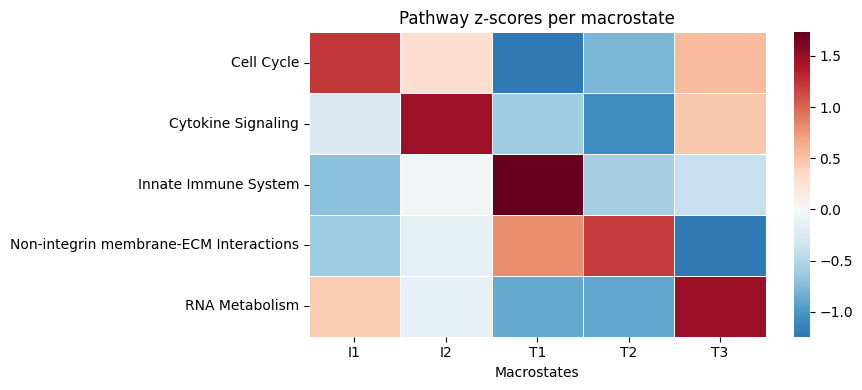

In [125]:
warnings.filterwarnings("ignore")
reactome = get_library(name="Reactome_Pathways_2024", organism="Human")
pathways = {
    "Cell Cycle": reactome["Cell Cycle Checkpoints"], # I1
    "Cytokine Signaling": reactome["Cytokine Signaling in Immune System"],  # I2
    "Innate Immune System": reactome["Innate Immune System"],  # T1
    "Non-integrin membrane-ECM Interactions": reactome["Non-integrin membrane-ECM Interactions"],  # T2
    "RNA Metabolism": reactome["Metabolism of RNA"],  # T3
}

# Compute score for each cell for each pathway
for name, gene_list in pathways.items():
    gene_list_filtered = [g for g in gene_list if g in adata_no_none.var_names]
    if len(gene_list_filtered) == 0:
        print(f"No genes found for {name}")
        continue
    sc.tl.score_genes(adata_no_none, gene_list=gene_list_filtered, score_name=name)

scores = list(pathways.keys())
mean_scores = (
    adata_no_none.obs
    .groupby("macrostates")[scores]
    .mean())

# Plot z-score for each macrostate per pathway
plt.figure(figsize=(9, 4))

mean_scores_z_all = mean_scores.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

sns.heatmap(mean_scores_z_all.T,cmap="RdBu_r",center=0,linewidths=0.5)

plt.title("Pathway z-scores per macrostate")
plt.xlabel("Macrostates")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_macrostates.png", dpi=300, bbox_inches="tight")
plt.show()

Pathways score on the HVG per macrostates 

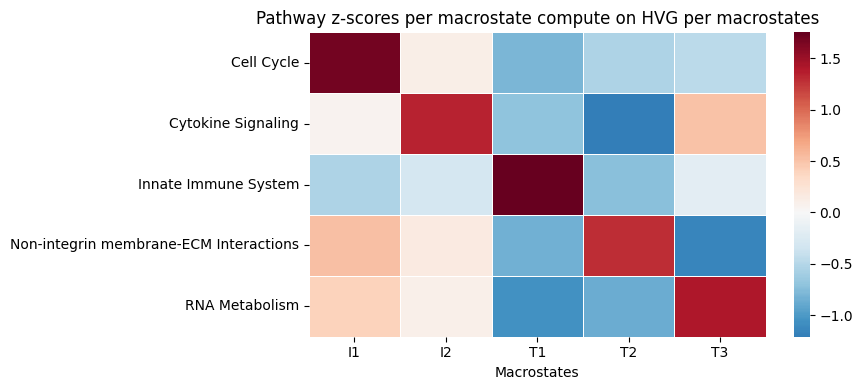

In [126]:
# Compute score for each cell for each pathway on the HVG per macrostates 
for name, gene_list in pathways.items():
    gene_list_filtered = [g for g in gene_list if g in adata_hvg.var_names]
    if len(gene_list_filtered) == 0:
        print(f"No genes found for {name}")
        continue
    sc.tl.score_genes(adata_hvg, gene_list=gene_list_filtered, score_name=name)

scores = list(pathways.keys())
mean_scores = (
    adata_hvg.obs
    .groupby("macrostates")[scores]
    .mean())

# Plot z-score for each macrostate per pathway
plt.figure(figsize=(9, 4))

mean_scores_z_hvg = mean_scores.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

sns.heatmap(mean_scores_z_hvg.T,cmap="RdBu_r",center=0,linewidths=0.5)

plt.title("Pathway z-scores per macrostate compute on HVG per macrostates")
plt.xlabel("Macrostates")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_macrostates_hvg.png", dpi=300, bbox_inches="tight")
plt.show()

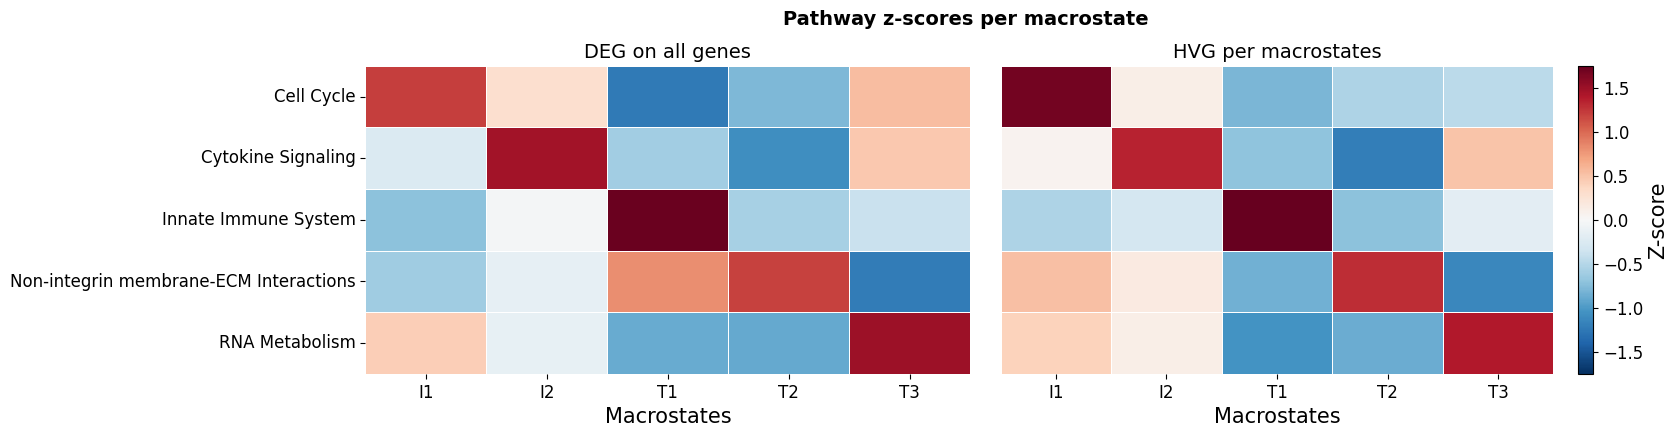

In [131]:
# Compute shared color scale
vmin = min(mean_scores_z_all.values.min(), mean_scores_z_hvg.values.min())
vmax = max(mean_scores_z_all.values.max(), mean_scores_z_hvg.values.max())
abs_max = max(abs(vmin), abs(vmax))

# Plot
TICK_FONTSIZE = 12
LABEL_FONTSIZE = 15
TITLE_FONTSIZE = 14

fig, axes = plt.subplots(1, 2, figsize=(16, 4),gridspec_kw={"wspace": 0.05, "width_ratios": [1, 1]})
fig.suptitle("Pathway z-scores per macrostate", fontsize=14, fontweight="bold", y=1.02)

# Left heatmap
sns.heatmap(
    mean_scores_z_all.T,
    cmap="RdBu_r", center=0,
    vmin=-abs_max, vmax=abs_max,
    linewidths=0.5,
    ax=axes[0],
    cbar=False,
    yticklabels=True
)
axes[0].set_title("DEG on all genes", fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel("Macrostates", fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=0)
axes[0].tick_params(axis='y', labelsize=TICK_FONTSIZE, rotation=0)

# Right heatmap
sns.heatmap(
    mean_scores_z_hvg.T,
    cmap="RdBu_r", center=0,
    vmin=-abs_max, vmax=abs_max,
    linewidths=0.5,
    ax=axes[1],
    cbar=False,
    yticklabels=False
)
axes[1].set_title("HVG per macrostates", fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel("Macrostates", fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel("")

axes[1].tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=0)

# Colorbar
sm = plt.cm.ScalarMappable(cmap="RdBu_r",
                            norm=plt.Normalize(vmin=-abs_max, vmax=abs_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label("Z-score", fontsize=LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_macrostates_combined.png", dpi=300, bbox_inches="tight")
plt.show()

# 4) Evaluate the binarization

Look at pathways selected in the binarised matrix

In [ ]:
reactome = get_library(name="Reactome_Pathways_2024", organism="Human")
pathways = {
    "Cell Cycle": reactome["Cell Cycle Checkpoints"], # I1
    "Cytokine Signaling": reactome["Cytokine Signaling in Immune System"],  # I2
    "Innate Immune System": reactome["Innate Immune System"],  # T1
    "Non-integrin membrane-ECM Interactions": reactome["Non-integrin membrane-ECM Interactions"],  # T2
    "RNA Metabolism": reactome["Metabolism of RNA"],  # T3
}

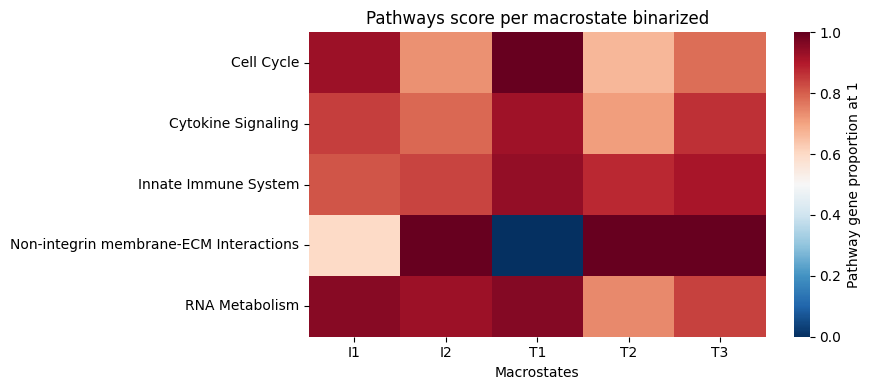

In [164]:
binary_matrix = pd.DataFrame.from_dict(binarized_states, orient="index").fillna(np.nan)
# Forcer conversion en float (pour garder NaN)
binary_matrix = binary_matrix.apply(pd.to_numeric, errors="coerce")

scores = {}

for name, genes in pathways.items():
    # keep genes only prsent in data_binarized
    genes_present = [g for g in genes if g in binary_matrix.columns]
    if len(genes_present) == 0:
        # pathway empthy
        scores[name] = pd.Series(np.nan, index=binary_matrix.index, dtype=float)
        continue

    mat = binary_matrix.loc[:, genes_present]

    num = (mat == 1).sum(axis=1)          # number of genes activated (=1) per macrostates
    den = mat.notna().sum(axis=1)         # number of 0 or 1, not NA
    score = num / den                     # if den > 0, else NaN

    scores[name] = score

scores_df = pd.DataFrame(scores)
order = ["I1", "I2", "T1", "T2", "T3"]
scores_df = scores_df.loc[order]
scores_df = scores_df.T

#Plot 
plt.figure(figsize=(9, 4))
sns.heatmap(scores_df,cmap="RdBu_r",vmin=0,vmax=1,annot=False,fmt=".2f",cbar_kws={"label": "Pathway gene proportion at 1"})
plt.title("Pathways score per macrostate binarized")
plt.xlabel("Macrostates")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_macrostates_percent_binarized.png", dpi=300, bbox_inches="tight")
plt.show()

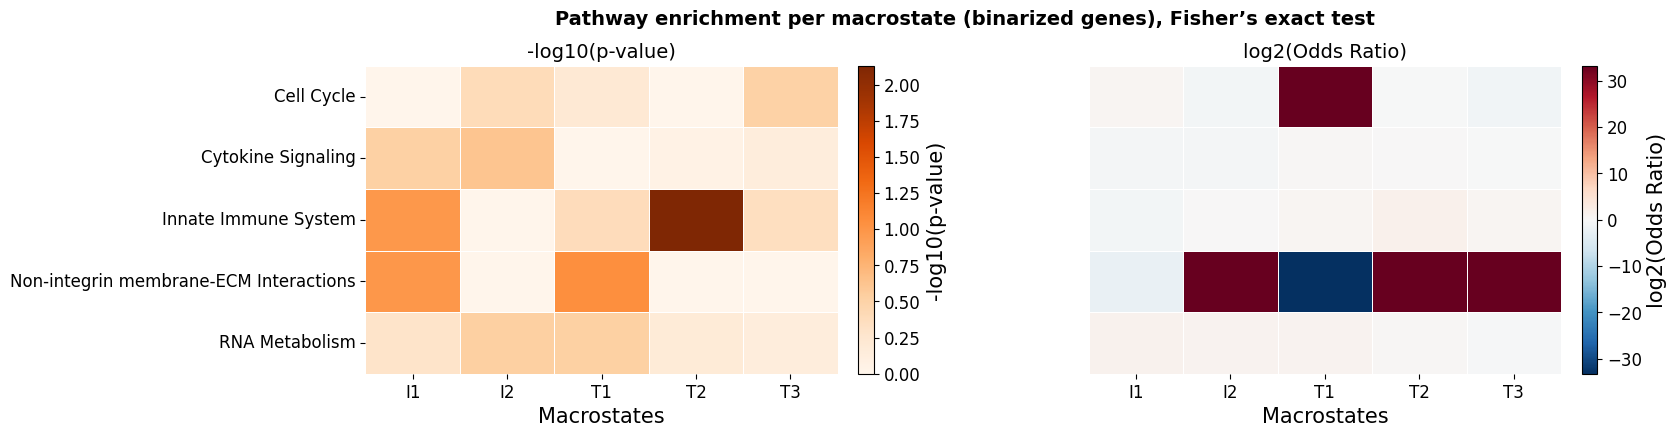

In [163]:
binary_matrix =binary_matrix.T
stats = {}
stats_or = {}

for pathway_name, gene_list in pathways.items():
    stats[pathway_name] = {}
    stats_or[pathway_name] = {}
    for state in binary_matrix.columns:
        state_vector = binary_matrix[state]
        genes = [g for g in gene_list if g in state_vector.index]
        if len(genes) == 0:
            continue
        
        # counts
        in_pathway = state_vector.loc[genes]
        out_pathway = state_vector.drop(index=genes)
        a = (in_pathway == 1).sum()
        b = (in_pathway == 0).sum()
        c = (out_pathway == 1).sum()
        d = (out_pathway == 0).sum()
        table = [[a, b], [c, d]]
        
        oddsratio, pval = fisher_exact(table)
        stats[pathway_name][state] = -np.log10(pval + 1e-10)
        # log2(OR)
        log2_or = np.log2(oddsratio + 1e-10)
        stats_or[pathway_name][state] = log2_or

stats_or_df = pd.DataFrame(stats_or)
stats_df = pd.DataFrame(stats)
order = ["I1", "I2", "T1", "T2", "T3"]
stats_df = stats_df.loc[order]
stats_or_df = stats_or_df.loc[order]

#Plots 
TICK_FONTSIZE = 12
LABEL_FONTSIZE = 15
TITLE_FONTSIZE = 14

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"wspace": 0.4, "width_ratios": [1, 1]})
fig.suptitle("Pathway enrichment per macrostate (binarized genes), Fisher’s exact test", fontsize=14, fontweight="bold", y=1.02)

# Left heatmap — -log10(p-value)
abs_max_pval = np.nanmax(np.abs(stats_df.T.values))
sns.heatmap(stats_df.T,cmap="Oranges",vmin=0, vmax=abs_max_pval,linewidths=0.5,ax=axes[0],cbar=False,yticklabels=True)
axes[0].set_title("-log10(p-value)", fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel("Macrostates", fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=0)
axes[0].tick_params(axis='y', labelsize=TICK_FONTSIZE, rotation=0)

sm1 = plt.cm.ScalarMappable(cmap="Oranges", norm=plt.Normalize(vmin=0, vmax=abs_max_pval))
sm1.set_array([])
cbar1 = fig.colorbar(sm1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label("-log10(p-value)", fontsize=LABEL_FONTSIZE)
cbar1.ax.tick_params(labelsize=TICK_FONTSIZE)

# Right heatmap — log2(Odds Ratio)
finite_or = stats_or_df.T.replace([np.inf, -np.inf], np.nan)
abs_max_or = np.nanmax(np.abs(finite_or.values))
or_clipped = stats_or_df.T.replace(np.inf, abs_max_or).replace(-np.inf, -abs_max_or)

sns.heatmap(or_clipped,cmap="RdBu_r", center=0,vmin=-abs_max_or, vmax=abs_max_or,linewidths=0.5,ax=axes[1],cbar=False,yticklabels=False)
axes[1].set_title("log2(Odds Ratio)", fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel("Macrostates", fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=0)

sm2 = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-abs_max_or, vmax=abs_max_or))
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label("log2(Odds Ratio)", fontsize=LABEL_FONTSIZE)
cbar2.ax.tick_params(labelsize=TICK_FONTSIZE)

plt.tight_layout()
plt.savefig(f"{output_directory}/pathway_enrichment_binarized.png", dpi=300, bbox_inches="tight")
plt.show()

In [154]:
binary_matrix = pd.DataFrame.from_dict(binarized_states, orient="index").fillna(np.nan)
# Active genes per macrostates 
print("=== Active genes per macrostate ===")
for macrostate in binary_matrix.index:
    row = binary_matrix.loc[macrostate].dropna()
    percent=(100*int((row==1).sum()))/len(row)
    print(f"{macrostate}: {int((row==1).sum())} active / {len(row)} total / {percent:.2f} % active")

=== Active genes per macrostate ===
I1: 694 active / 784 total / 88.52 % active
I2: 768 active / 916 total / 83.84 % active
T2: 404 active / 590 total / 68.47 % active
T3: 726 active / 828 total / 87.68 % active
T1: 531 active / 583 total / 91.08 % active
